# Przepraszam, z kim rozmawiam?
Wariant **B**  
Projekt wykonuje: **Łukasz Walancik**

In [1]:
import io
import zipfile
import urllib.request
from pathlib import Path
import pandas as pd

# --- Params ---
participant_id = 'MW_SSH_05'
transcripts_dir = Path('transcripts')  # extracted CSVs will be placed here
transcripts_dir.mkdir(parents=True, exist_ok=True)

# --- Ensure TRANSCRIPTS.zip is downloaded & extracted ---
zip_url = 'https://zenodo.org/records/15222484/files/TRANSCRIPTS.zip?download=1'
expected_csv = transcripts_dir / f'{participant_id}.csv'

if not expected_csv.exists():
    print('Downloading TRANSCRIPTS.zip from Zenodo...')
    with urllib.request.urlopen(zip_url) as resp:
        data = resp.read()
    with zipfile.ZipFile(io.BytesIO(data)) as zf:
        zf.extractall(transcripts_dir)
    print(f'Extracted transcripts to: {transcripts_dir.resolve()}')
else:
    print('Transcripts already present, skipping download.')

# --- Load problems and responses from Zenodo ---
problems = pd.read_csv('https://zenodo.org/records/15222484/files/PROBLEMS.csv')
responses = pd.read_csv('https://zenodo.org/records/15222484/files/PROBLEMS_RESPONSES.csv')
merged_problems = pd.merge(responses, problems, on='problem_id', how='inner')

# Use column names as defined in the dataset docs
prediction_features = ['participant_decision', 'participant_certaintity', 'model_class', 'model_probability']
print(merged_problems[merged_problems['participant_id'] == participant_id][prediction_features])

# --- Retrieve transcript text for problem __P1__ for the participant ---
transcripts = pd.read_csv(expected_csv)
# Forward-fill problem markers within the participant's transcript
if 'problem_id' in transcripts.columns:
    transcripts['problem_id'] = transcripts['problem_id'].ffill()
    subset = transcripts[transcripts['problem_id'] == '__P1__']
else:
    subset = pd.DataFrame()

# Show key columns if present
cols = [c for c in ['speaker_id', 'slide_id', 'question_id', 'problem_id', 'text'] if c in subset.columns]
print(subset[cols] if cols else subset)

Extracted transcripts to: /content/transcripts
   participant_decision participant_certaintity model_class model_probability
57              trujący           średnio pewny     jadalny              0,54
58              jadalny           średnio pewny     jadalny              0,95
59              jadalny      zdecydowanie pewny     trujący                 1
    speaker_id slide_id question_id problem_id  \
180  MW_SSH_05      NaN         NaN     __P1__   
181         MW      NaN         NaN     __P1__   
182  MW_SSH_05      NaN         NaN     __P1__   

                                                  text  
180        Ok. Średnica 17,30... Mogę po całej kartce?  
181               Jasne, proszę sobie mazać spokojnie.  
182  Ok to wróćmy do… To była wysokość, średnica ka...  


## Zapoznanie się z danymi

Myślę, że warto zrobić podsumowanie tego jak dostępne dane faktycznie wygladają. Z opisu wynikałoby, że każdy użytkownik odpowiedział na 17 pytań, ale czy tak jest na pewno? Albo, że każdy, poza DE rozwiązał 3 problemy, ale czy na pewno? Ciekawią mnie też metadane, jak długość wszystkich wypowiedzi osoby badanej w transkrypcie, średnia długość odpowiedzi na pytanie, średnia długość wypowiedzi na slajd, itd.

In [ ]:
from collections import Counter

### Ile plików mamy, i dlaczego nie 39?

Ciekawe,: w pracy jest mowa o 39 uczestnikach, i z tego co pamiętam o 13 ekspertach. W takim razie w plikach brakuje jednego eksperta.

In [ ]:
licznik = Counter()
for transcript in transcripts_dir.glob('*.csv'):
  klasa = transcript.name.split('_')[1]
  licznik[klasa] += 1
print(licznik)
print(licznik.total())

Counter({'SSH': 18, 'DE': 12, 'IT': 8})
38


### Ile pytań widnieje w transkrypcie?

Też w sumie ciekawe, że w niektórych transkryptach nie ma 17 pytań obecnych. Pytanie, czy to wynika z tego, że nie zadano ich w badaniu, czy może to jest jakiś błąd w oznaczaniu transkryptów? No i jeśli nie zadano ich w badaniu, to na ile posługiwanie się pytaniami do klasyfikacji może być miarodajne?

In [ ]:
licznik_pytan = Counter()
for transcript_path in transcripts_dir.glob('*.csv'):
  transcript_file = pd.read_csv(transcript_path)
  questions_column = transcript_file['question_id'].dropna().unique()
  # print(len(questions_column), transcript_path)
  licznik_pytan[len(questions_column)] += 1
print(licznik_pytan)

Counter({17: 20, 16: 4, 14: 3, 15: 2, 12: 2, 4: 1, 6: 1, 11: 1, 0: 1, 13: 1, 10: 1, 9: 1})


### Ile problemów widnieje w transkrypcie?

Okej w problemach jest spójnie z opisem, no bo IT i SSH rozwiązują problemy, a 12 ekspertów (chociaż powinno być 13) nie rozwiązuje

In [ ]:
licznik_problemow = Counter()
for transcript_path in transcripts_dir.glob('*.csv'):
  transcript_file = pd.read_csv(transcript_path)
  problems_column = transcript_file['problem_id'].dropna().unique()
  # print(len(questions_column), transcript_path)
  licznik_problemow[len(problems_column)] += 1
print(licznik_problemow)

Counter({3: 26, 0: 12})


### Ile slajdów widnieje w transkrypcie?

W pliku "ORIGINAL_VISUALIZATIONS.pdf" znajduje się 15 slajdów. W kolumnie "slide_id", poza faktycznymi numerami slajdów występują też specjalne znaczniki, określający początek badania znaczknik "`__S000__`", określający początek sekcji poprawiania slajdów znacznik "`__S99__`", oraz określający początek sekcji rozwiązaywania problemów znacznik "`__S88__`". W grupach IT oraz SSH, teoretycznie każdy widział 15 slajdów, dokonywał popraw slajdów i rozwiązywał problemy. Daje to 18 unikalnych znaczników w kolumnie. Dla grupy DE, która nie rozwiązywała problemów, ani nie poprawiała slajdów, powinno być 16 unikalnych znaczników. Hmmm ale nie jestem teraz pewien jak to było opisane w pracy, czy może DE nie odpowiadali na niektóre pytania?

In [ ]:
licznik_slajdow = Counter()
for transcript_path in transcripts_dir.glob('*.csv'):
  transcript_file = pd.read_csv(transcript_path)
  slides_column = transcript_file['slide_id'].dropna().unique()
  # print(len(slides_column), transcript_path)
  licznik_slajdow[len(slides_column)] += 1
print(licznik_slajdow)

Counter({17: 15, 18: 9, 16: 8, 15: 3, 14: 2, 13: 1})


### Podsumowanie?

Jak można podzielić dane, które mamy dostępne? Zastanówmy się póki co nad samymi transkryptami, no bo tam jest główna zawartość, z której można korzystać. Mamy 38 plików. Każdy z tych plików można teoretycznie podzielić na podstawie:
- slajdów - kolumna `slide_id`.
- pytań - kolumna `question_id`
- problemów - kolumna `problem_id`

Problem pojawia się z kolumną z problemami, no bo DE nie odpowiadali na problemy. Taki podział można by więc zastosować do SSH i IT. Pytanie też brzmi, czy podział na podstawie pytań to dobry pomysł. Patrząc na rozstrzał, który pojawia się w trankryptach, gdzie niektóre transkrypty mają 0, 4 czy 6 pytań, a inne po 17 pytań.

Wydaje mi się, że jest kilka potencjalnych, 'dobrych' podziałów.  

Pierwszy to podział na podstawie slajdów, chociaż tu też trzeba się będzie lepiej przypatrzeć temu jak to wygląda.


Drugim dobrym podziałem, może dobrym, jest po prostu podział na zdania wypowiadane przez uczestników. Czyli rozdzielenie całego tekstu na podstawie kropki.
Jest też pytanie na jakiej podstawie niektóre wypowiedzi zostały podzielone na kilka sąsiadujących ze sobą komórek. Na przykład w pliku "MW_SSH_05.csv" mamy linijki 73 i 74, które pokazują wypowiedzi uczestnika. Ale dlaczego ta wypowiedź została podzielona na dwie osobne komórki?  

Teoretycznie trzecim ciekawym, potencjalnie dobrym podziałem jest podział właśnie na podstawie całych komórek.

### Czyszczenie tekstu

Analizując tekst widoczny w kolumnie `text` zauważyłem, że pojawia się tam wiele elementów, które mogą być niepożądane w procesie uczenia modelu.
Niektóre z 'podejrzanych' rzeczy, to:
* (ns - 01:26:55)
* [śmiech]
* [przez]
* [niesłyszalne]
* [mówi po cichu]
* [niewyraźne]
* [ang.]
* [czyta półgłosem wykres]
* [w sali 3.119 tablica się sama rozwija i zwija co jakiś czas]
* (anonimizacja)
* [anonimizacja]
* \u200b
* [westchnienie]
* [czyta po cichu.]
* [z poprzednią kartką z przeanalizowanym przykładam]
* [odtwarzanie nagrania cd.]
* [Koniec części pierwszej]
* (od tego momentu mówi znowu )
* [ANONIMIZACJA]

Widzę tutaj trzy główne typy potencjalnie niepożądanych rzeczy.  

Po pierwsze, znaczniki, czy tagi, zakładam, że dodane ręcznie do transkryptów, zaznaczające westchnięcia, śmiechy, anonimizację itd. Co ciekawe, to widać tutaj, że albo robiła je jedna osoba, która była bardzo niespójna, albo, co bardziej prawdopodobne, robiło to kilka osób [anonimizacja], (anonimizacja), [ANONIMIZACJA]. Te znaczniki mają format nawias kwadratowy otwierający, tekst, nawias kwadratowy zamykający. No i pytanie brzmi, czy takich elementów powinno się pozbyć z tekstu, czy może mogą one stanowić poszlakę klasy osoby mówiącej. Może eksperci częściej się śmieją? Albo studenci informatyki częściej wzdychają?

Po drugie, w zasadzie podobne do tych pierwszych, ale troszkę innne, znaczniki zawierające w sobie zakładam znacznik czasu w nagraniu, i informację o tym, że coś było niesłyszalne - (ns - 01:26:55). Hmm myślę teraz, że to jest pewnie kolejna oznaka niespójności wśród badaczy tagujących transkrypty.

Po trzecie, od czasu do czasu w tekście pojawiają się takie oto ciekawostki: `\u200b` Sam nie jestem pewien skąd się to mogło wziąć.

Oprócz tego, występują komórki zawierające jedynie znak `~`

W związku z powyższym, myślę, że warto byłoby stworzyć metodę clean_text, która będzie zajmowała się czyszczeniem tekstu.

## Klasa Transcript

In [42]:
class Transcript:
    def _parse_file_name(self) -> list[str]:
        fragments = self.path.stem.split('_')
        if len(fragments) != 3:
            raise ValueError(f"Wrong file name structure: {self.path.name}")
        return fragments

    def __init__(self, transcript_path: Path):
        self.path = transcript_path
        self.investigator_code, self.participant_group, self.participant_id = self._parse_file_name()
        self.data = pd.read_csv(transcript_path)
        self.data['slide_id'] = self.data['slide_id'].ffill()
        self.data['question_id'] = self.data['question_id'].ffill()

        no_question_slides = ['__S15__', '__S88__', '__S99__']
        self.data.loc[self.data['slide_id'].isin(no_question_slides), 'question_id'] = None # Removes question ids stretching outside their logical area

    def _filter_by_speaker(self, speaker='participant'):
        if speaker == 'investigator':
            filtered_data = self.data[self.data['speaker_id'] == self.investigator_code]
        elif speaker == 'participant':
            filtered_data = self.data[self.data['speaker_id'] != self.investigator_code]
        elif speaker == 'both':
            filtered_data = self.data
        else:
            raise ValueError(f"'{speaker}' is not accepted as speaker argument. Use 'investigator', 'participant' or 'both'")
        return filtered_data

    def get_utterances(self, speaker="participant"):
        return self._filter_by_speaker(speaker)['text'].dropna().to_list()

    def get_text_by_slides(self, speaker='participant'):
        filtered_data = self._filter_by_speaker(speaker)
        return filtered_data.groupby('slide_id')['text'].apply(list).to_dict()

    def get_text_by_questions(self, speaker='participant'):
        filtered_data = self._filter_by_speaker(speaker)
        return filtered_data.groupby('question_id')['text'].apply(list).to_dict()

    def analyze_questions(self, speaker='participant'):
        text_by_questions = self.get_text_by_questions(speaker)
        rows = []
        participant_code = self.path.stem
        for question_id, question_cells in text_by_questions.items():
            question_text = ' '.join(question_cells)
            question_sentences = [sentence for sentence in question_text.split('.') if sentence.strip()]
            question_words = question_text.split()
            row = {'participant_code': participant_code,
                   'participant_group': self.participant_group,
                   'question_id': question_id,
                   'cells_count': len(question_cells),
                   'sentences_count': len(question_sentences),
                   'words_count': len(question_words),
                   'characters_count': len(question_text)}
            rows.append(row)

        return pd.DataFrame(rows)

    def analyze_slides(self, speaker='participant'):
        text_by_slides = self.get_text_by_slides(speaker)
        rows = []
        participant_code = self.path.stem
        for slide_id, slide_cells in text_by_slides.items():
            slide_text = ' '.join(slide_cells)
            slide_sentences = [sentence for sentence in slide_text.split('.') if sentence.strip()]
            slide_words = slide_text.split()
            row = {'participant_code': participant_code,
                   'participant_group': self.participant_group,
                   'slide_id': slide_id,
                   'cells_count': len(slide_cells),
                   'sentences_count': len(slide_sentences),
                   'words_count': len(slide_words),
                   'characters_count': len(slide_text)}
            rows.append(row)

        return pd.DataFrame(rows)

In [43]:
t1 = Transcript(Path('/content/transcripts/DR_IT_05.csv'))

In [44]:
print(t1.investigator_code)
print(t1.participant_group)
print(t1.participant_id)

DR
IT
05


## Analiza Slajdów

Tutaj będę analizował długości wypowiedzi w zależności od slajdu, z podziałem na poszczególne grupy

In [45]:
t1.analyze_slides().head()

,participant_code,participant_group,slide_id,cells_count,sentences_count,words_count,characters_count
0,DR_IT_05,IT,__S10__,45,50,417,2757
1,DR_IT_05,IT,__S11__,17,14,143,965
2,DR_IT_05,IT,__S12__,31,7,244,1504
3,DR_IT_05,IT,__S13__,58,54,603,3937
4,DR_IT_05,IT,__S1__,1,2,17,109


In [46]:
all_dataframes = []
for transcript_path in transcripts_dir.glob('*.csv'):
  t = Transcript(transcript_path)
  analysis = t.analyze_slides()
  all_dataframes.append(analysis)

In [47]:
global_dataframe = pd.concat(all_dataframes, ignore_index=True)

In [48]:
unique_slides = global_dataframe['slide_id'].unique().tolist()
sorted_slides = sorted(unique_slides, key = lambda x: int(x.strip('_S')))

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

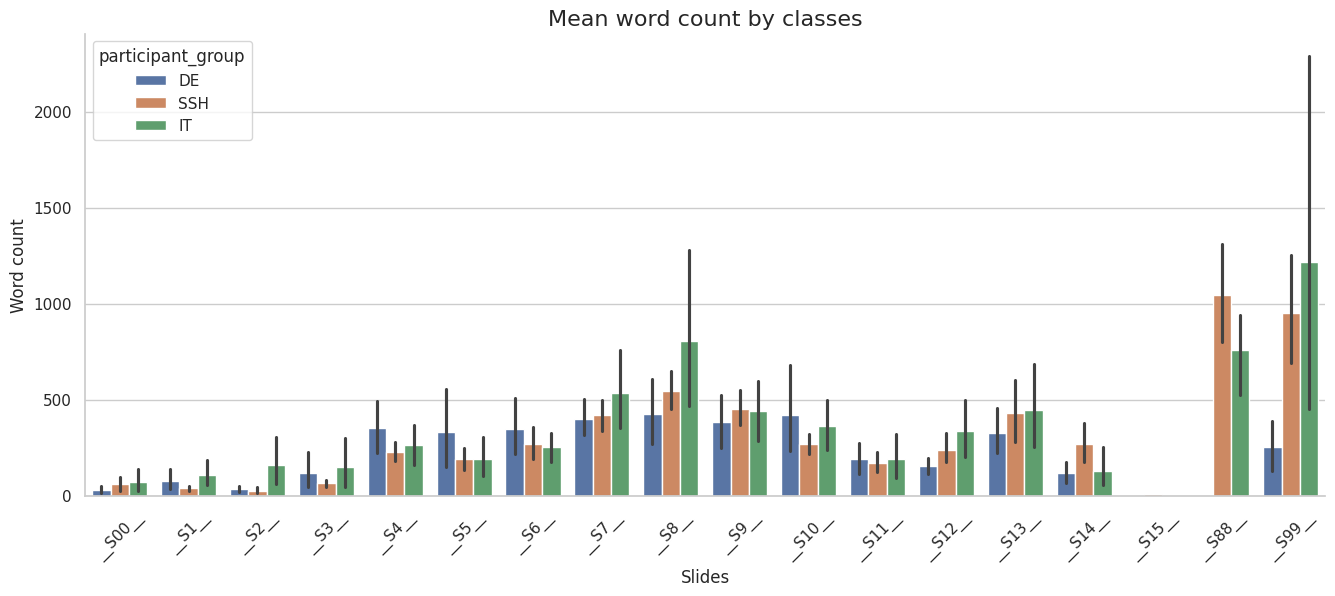

In [50]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))
sns.barplot(
    data=global_dataframe,
    x='slide_id',
    y='words_count',
    hue='participant_group',
    order=sorted_slides,
)

plt.xticks(rotation=45)
plt.title('Mean word count by classes', fontsize=16)
plt.xlabel('Slides', fontsize=12)
plt.ylabel('Word count', fontsize=12)

sns.despine()

plt.show()

## Analiza Pytań

### UWAGA !!!
Analiza pytań wymaga dopracowania. Zrobienie forward fill dla pytań sprawi, że ostatnie zadane pytanie (niekoniecznie 17) zostanie rozszerzone na całą resztę pliku! Należy poprawić albo proces robienia forward fill, albo gdzieś indziej to naprawić!!!

In [51]:
t1.analyze_questions().head()

,participant_code,participant_group,question_id,cells_count,sentences_count,words_count,characters_count
0,DR_IT_05,IT,__Q10__,12,15,159,1007
1,DR_IT_05,IT,__Q11__,7,12,131,771
2,DR_IT_05,IT,__Q12__,13,15,169,1056
3,DR_IT_05,IT,__Q13__,47,45,373,2528
4,DR_IT_05,IT,__Q14__,19,22,227,1435


In [52]:
all_dataframes = []
for transcript_path in transcripts_dir.glob('*.csv'):
  t = Transcript(transcript_path)
  analysis = t.analyze_questions()
  all_dataframes.append(analysis)
global_dataframe = pd.concat(all_dataframes, ignore_index=True)

unique_questions = global_dataframe['question_id'].unique().tolist()
sorted_questions = sorted(unique_questions, key = lambda x: int(x.strip('_Q')))

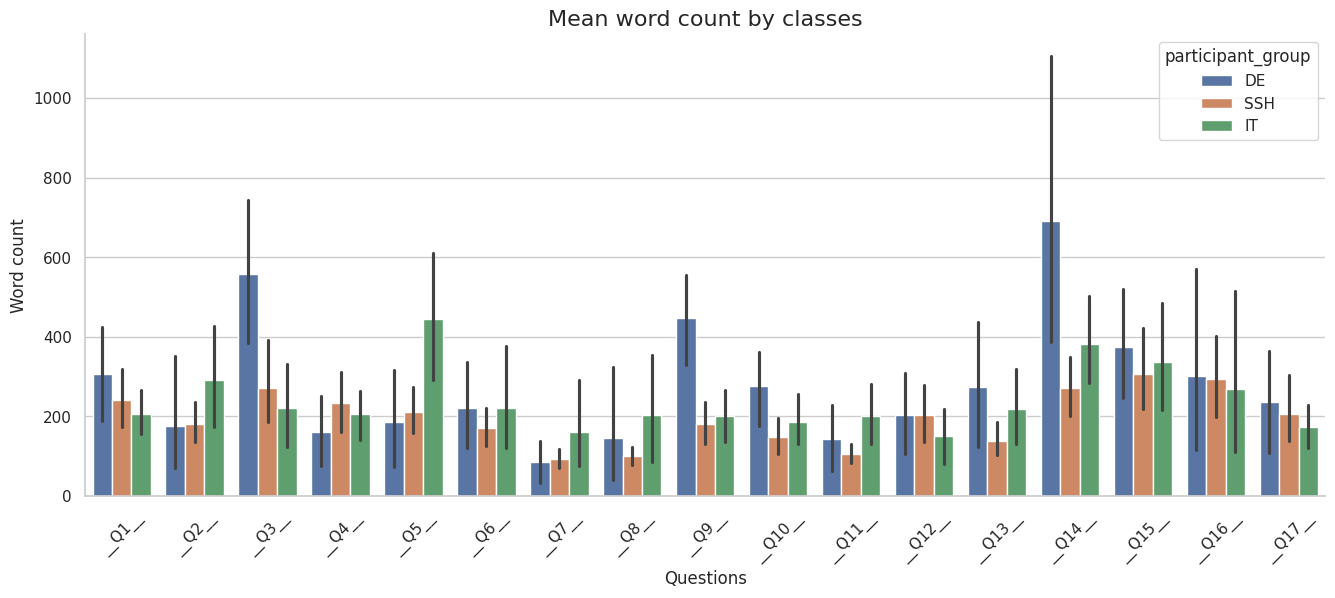

In [53]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))
sns.barplot(
    data=global_dataframe,
    x='question_id',
    y='words_count',
    hue='participant_group',
    order=sorted_questions,
)

plt.xticks(rotation=45)
plt.title('Mean word count by classes', fontsize=16)
plt.xlabel('Questions', fontsize=12)
plt.ylabel('Word count', fontsize=12)

sns.despine()

plt.show()